# Homework 02: Multi-Class Classification with Neural Networks

## Due: Midnight on September 14 (with 2-hour grace period) and worth 85 points

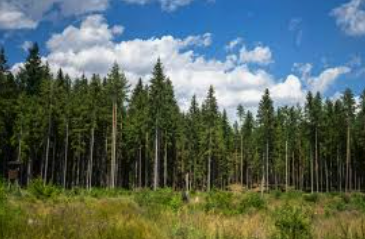

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


## Imports

In [361]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

sns.set_theme(font_scale=0.8) 
# plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 8
plt.rcParams['lines.linewidth'] = 0.5
# plt.rcParams['lines.markersize'] = 3
plt.rcParams['axes.edgecolor']  = 'gray'
plt.rcParams['xtick.color']     = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.color'] = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8

## Utility functions

In [362]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history, title="Training and Validation Metrics"):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))
    fig.suptitle(title, fontsize=12)

    ax1.plot(epochs, history.history['loss'], 'r-o', label='Training Loss', markersize=3)
    ax1.plot(epochs, history.history['val_loss'], 'b-o', label='Validation Loss', markersize=3)
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss over Epochs')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(epochs, history.history['accuracy'], 'r-o', label='Training Accuracy', markersize=3)
    ax2.plot(epochs, history.history['val_accuracy'], 'b-o', label='Validation Accuracy', markersize=3)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05)
    ax2.set_title('Accuracy over Epochs')
    ax2.grid(True)
    ax2.legend(loc='upper left')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')
    print(f'Final Validation Accuracy: {final_val_acc:.4f}')

In [363]:
# Print out loss and accuracy learning curves

def plot_training(history):
    
    # Plot Loss (RMSE)
    plt.figure(figsize=(8, 5))
    plt.title('Cross-Entropy Loss over Epochs')
    plt.plot(range(1, len(history.history['loss']) + 1),
             history.history['loss'],
             label='Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid()
    plt.show()
    
    a = history.history['loss'][-1]
    print(f'Final Loss: {a:.4f}')
    
    # Plot Accuracy
    plt.figure(figsize=(8, 5))
    plt.title('Accuracy over Epochs')
    plt.plot(range(1, len(history.history['loss']) + 1),
             history.history['accuracy'],
             label='Accuracy')
    plt.xlabel('Epochs')
    plt.ylim(0,1.05)
    plt.legend(loc='upper left')
    plt.grid()
    plt.show()
    
    a = history.history['accuracy'][-1]
    print(f'Final Accuracy: {a:.4f}')
    print()



## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [364]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y = True)   # y in {1..7}
classes, counts = np.unique(y, return_counts = True)
min_count       = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0...,6 for Keras
print(f"Subset shape: {X_sub.shape},\nClass counts: {Counter(y_sub)}")


Subset shape: (19229, 54),
Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify = y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size = 0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [365]:
# 1. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size = 0.2, random_state = random_seed, stratify = y_sub
)

# 2. Standardize features
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



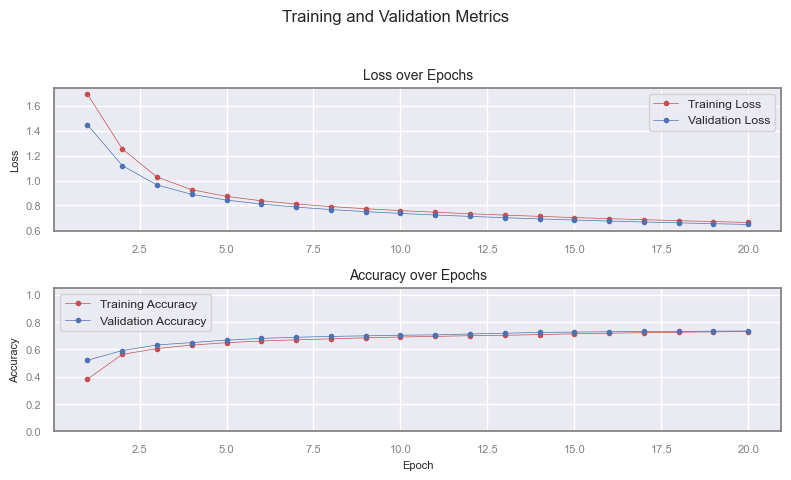

Final Training Loss:     0.6639
Final Training Accuracy: 0.7306
Final Validation Accuracy: 0.7343


In [366]:
num_epochs  = 20
batch_size  = 32
lr          = 0.0001


# 1. Build the model
baseline_model = Sequential([
    Input(shape = (X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')
])

# 2. Compile 
baseline_model.compile(
    optimizer   = Adam(learning_rate = lr),
    loss        = 'sparse_categorical_crossentropy',
    metrics     = ['accuracy']
)

# 3. Train
history = baseline_model.fit(
    X_train_scaled, y_train,
    epochs       = num_epochs,
    batch_size   = batch_size,
    validation_data=(X_test_scaled, y_test),
    verbose      = 0
)

# 4. Plot training loss and accuracy
plot_history(history)

In [367]:
train_accuracies = history.history['accuracy']

#  epoch 20 -->  index 19
accuracy_epoch_20 = train_accuracies[19]

print(f"Training accuracy at epoch 20: {accuracy_epoch_20:.4f}")

Training accuracy at epoch 20: 0.7306


In [368]:
# Set a1a to the final TRAINING accuracy at epoch 20

a1a = accuracy_epoch_20            # Replace 0.0 with your answer

In [369]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7306


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!


--- Training with Batch Size: 4 ---


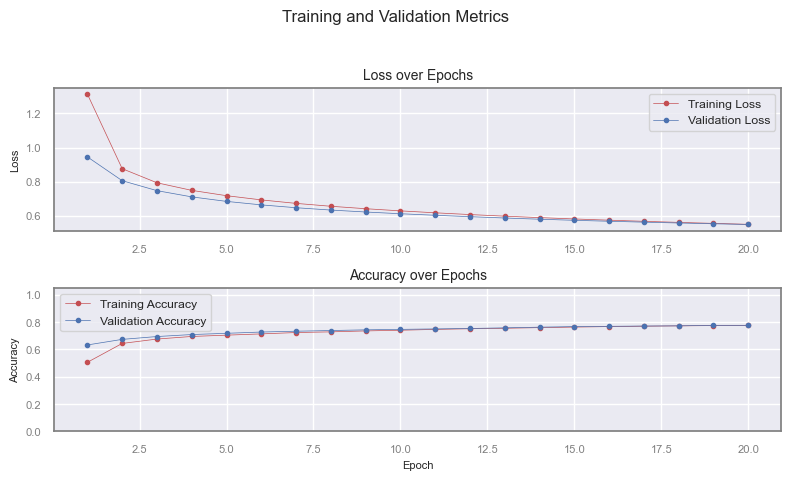

Final Training Loss:     0.5505
Final Training Accuracy: 0.7759
Final Validation Accuracy: 0.7759

--- Training with Batch Size: 8 ---


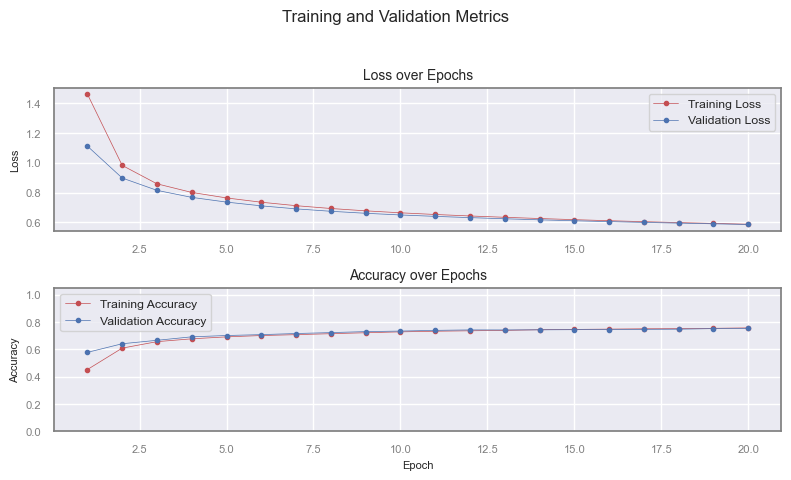

Final Training Loss:     0.5871
Final Training Accuracy: 0.7571
Final Validation Accuracy: 0.7535

--- Training with Batch Size: 16 ---


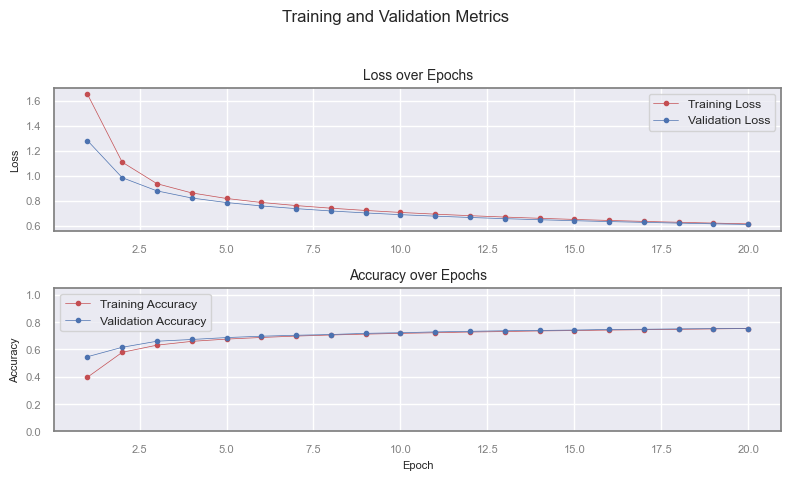

Final Training Loss:     0.6150
Final Training Accuracy: 0.7525
Final Validation Accuracy: 0.7520

--- Training with Batch Size: 128 ---


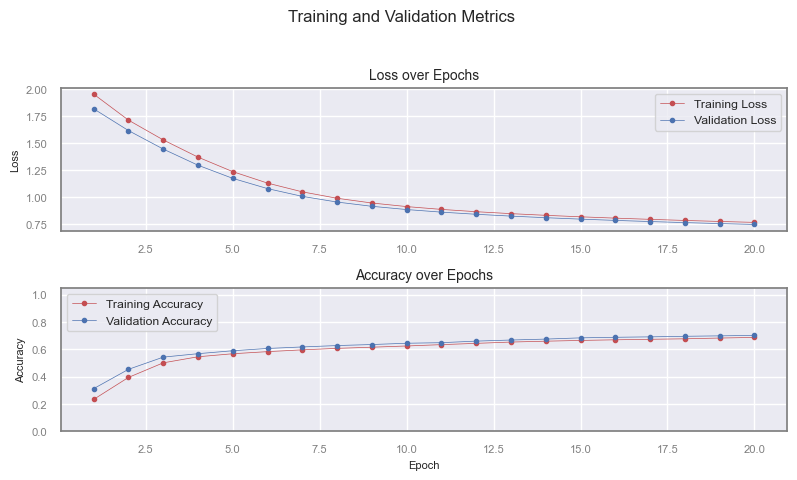

Final Training Loss:     0.7659
Final Training Accuracy: 0.6873
Final Validation Accuracy: 0.7020

Best batch size: 4
Best training accuracy: 0.7759
Best validation accuracy: 0.7759


,Batch Size,Training Accuracy,Validation Accuracy
0,4,0.775921,0.775871
1,8,0.757069,0.753510
2,16,0.752519,0.751950
3,128,0.687252,0.702028


In [370]:
# Your code here

batch_sizes = [4, 8, 16, 128]
num_epochs  = 20
lr          = 0.0001
results     = {}

for batch_size in batch_sizes:
    print(f"\n--- Training with Batch Size: {batch_size} ---")
    
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model = Sequential([
        Input(shape = (X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])
    
    model.compile(
        optimizer   = Adam(learning_rate = lr),
        loss        = 'sparse_categorical_crossentropy',
        metrics     = ['accuracy']
    )
    
    history = model.fit(
        X_train_scaled, y_train,
        epochs          = num_epochs,
        batch_size      = batch_size,
        validation_data = (X_test_scaled, y_test),
        verbose         = 0
    )
    
    plot_history(history)
    
    final_val_acc = history.history['val_accuracy'][-1]
    final_training_acc = history.history['accuracy'][-1]
    # print(f"Final Training Accuracy: {final_training_acc:.4f}")
    # add both accuracies to results
    results[batch_size] = (final_training_acc, final_val_acc)

# Find the batch size with the highest training accuracy
best_batch_size = max(results, key=lambda k: results[k][0])
best_training_accuracy = results[best_batch_size][0]
best_validation_accuracy = results[best_batch_size][1]

print(f"\nBest batch size: {best_batch_size}\nBest training accuracy: {best_training_accuracy:.4f}\nBest validation accuracy: {best_validation_accuracy:.4f}")

# construct a dataframe from results. The first column is batch size, second is training accuracy, third is validation accuracy
results_df = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in results.items()],
    columns=['Batch Size', 'Training Accuracy', 'Validation Accuracy']
)

results_df

In [371]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = best_batch_size             # Replace 0 with your answer

In [372]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [373]:
# Set a2b to the best accuracy score found

a2b = best_training_accuracy         # Replace 0.0 with your answer

In [374]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7759


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.



--- Training with Learning Rate: 0.001 ---


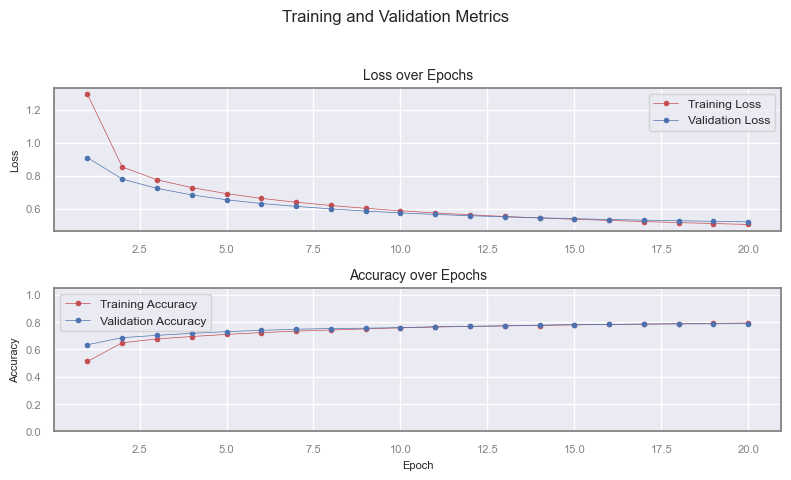

Final Training Loss:     0.5057
Final Training Accuracy: 0.7930
Final Validation Accuracy: 0.7876

--- Training with Learning Rate: 0.0005 ---


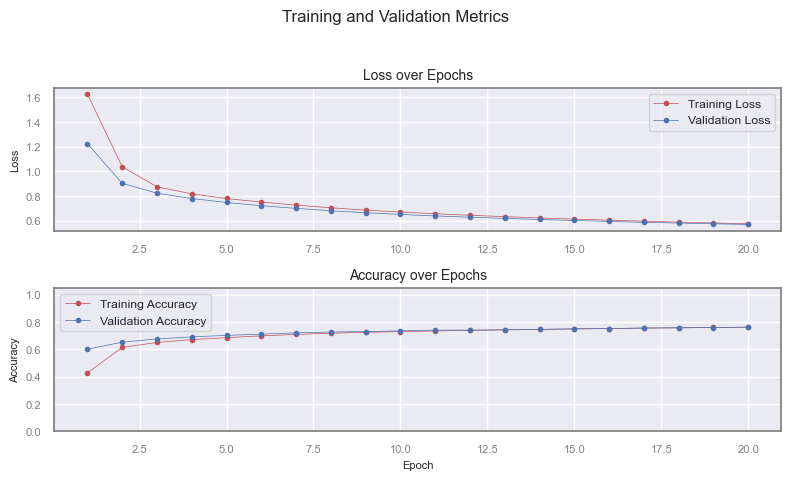

Final Training Loss:     0.5749
Final Training Accuracy: 0.7626
Final Validation Accuracy: 0.7621

--- Training with Learning Rate: 0.0001 ---


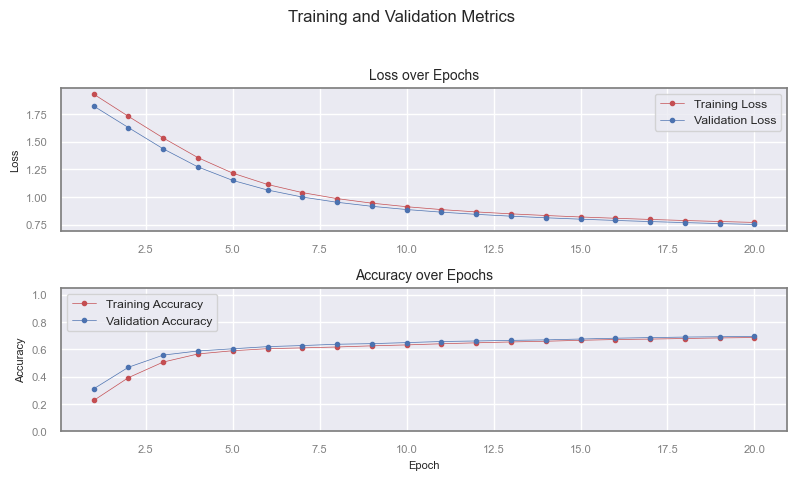

Final Training Loss:     0.7710
Final Training Accuracy: 0.6863
Final Validation Accuracy: 0.6953

--- Training with Learning Rate: 5e-05 ---


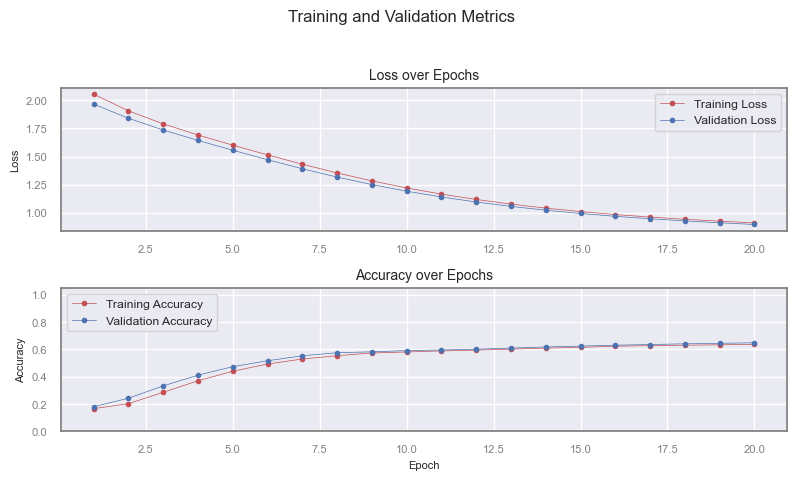

Final Training Loss:     0.9099
Final Training Accuracy: 0.6363
Final Validation Accuracy: 0.6479

--- Training with Learning Rate: 1e-05 ---


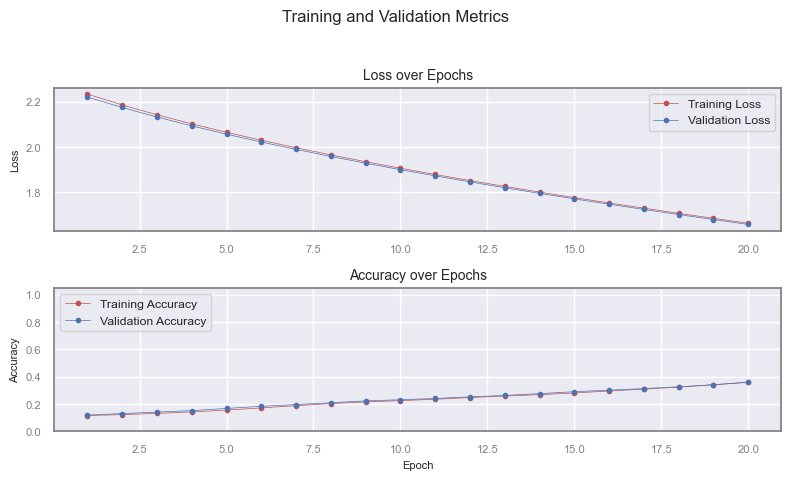

Final Training Loss:     1.6644
Final Training Accuracy: 0.3584
Final Validation Accuracy: 0.3593

Best Learning Rate: 0.001, final training accuracy of: 0.7930, final validation accuracy of: 0.7876


,Learning Rate,Training Accuracy,Validation Accuracy
0,0.00100,0.792953,0.787571
1,0.00050,0.762595,0.762091
2,0.00010,0.686342,0.695268
3,0.00005,0.636287,0.647946
4,0.00001,0.358448,0.359334


In [375]:
# Your code here

num_epochs = 20
learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

results_lr = {}


for lr in learning_rates:
    print(f"\n--- Training with Learning Rate: {lr} ---")
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    # Create the model again to reset weights for each experiment
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])
    
    # Compile the model with the current learning rate
    model.compile(
        optimizer   = Adam(learning_rate = lr),
        loss        = 'sparse_categorical_crossentropy',
        metrics     = ['accuracy']
    )
    
    
    # Train the model
    history = model.fit(
        X_train_scaled, y_train,
        epochs          = num_epochs,
        batch_size      = batch_size,
        validation_data = (X_test_scaled, y_test),
        verbose         = 0
    )
    
    plot_history(history)
    
    # Get  final  accuracy
    final_training_accuracy = history.history['accuracy'][-1]
    final_val_accuracy = history.history['val_accuracy'][-1]
    results_lr[lr] = (final_training_accuracy, final_val_accuracy)

# learning rate with  best accuracy
best_lr             = max(results_lr, key=lambda k: results_lr[k][0])
best_training_accuracy_lr = results_lr[best_lr][0]
best_validation_accuracy_lr = results_lr[best_lr][1]

print(f"\nBest Learning Rate: {best_lr}, final training accuracy of: {best_training_accuracy_lr:.4f}, final validation accuracy of: {best_validation_accuracy_lr:.4f}")

# construct a dataframe from results. The first column is batch size, second is training accuracy, third is validation accuracy
results_df_lr = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in results_lr.items()],
    columns=['Learning Rate', 'Training Accuracy', 'Validation Accuracy']
)
results_df_lr

In [376]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = best_lr           # Replace 0.0 with your answer

In [377]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [378]:
# Set a3b to the accuracy found by the best learning rate

a3b = best_training_accuracy_lr          # Replace 0.0 with your answer

In [379]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7930


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.


--- Training w/ Cosine Decay (Initial Learning Rate = 0.01) ---


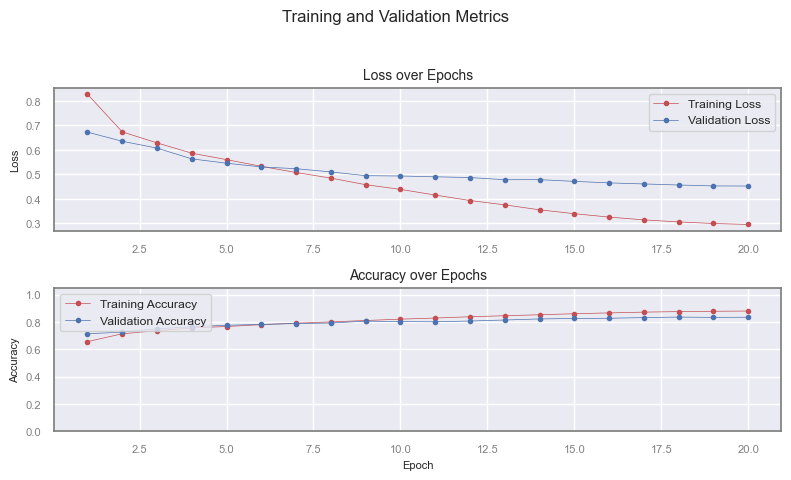

Final Training Loss:     0.2961
Final Training Accuracy: 0.8803
Final Validation Accuracy: 0.8352

--- Training w/ Cosine Decay (Initial Learning Rate = 0.005) ---


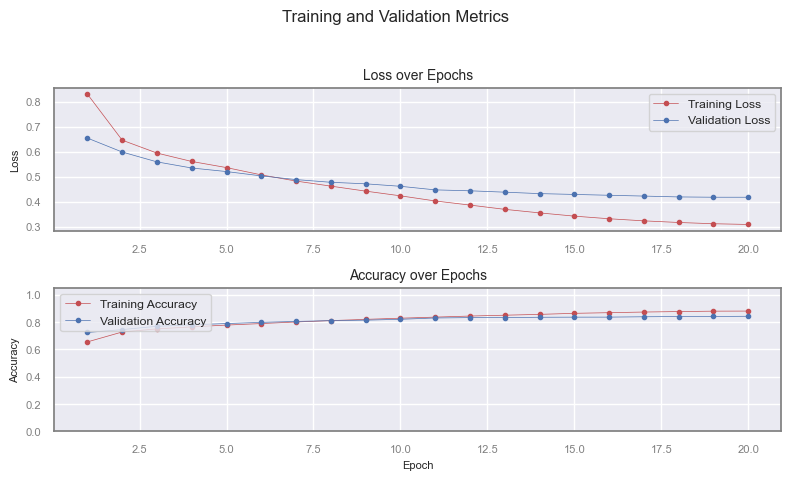

Final Training Loss:     0.3094
Final Training Accuracy: 0.8802
Final Validation Accuracy: 0.8422

--- Training w/ Cosine Decay (Initial Learning Rate = 0.001) ---


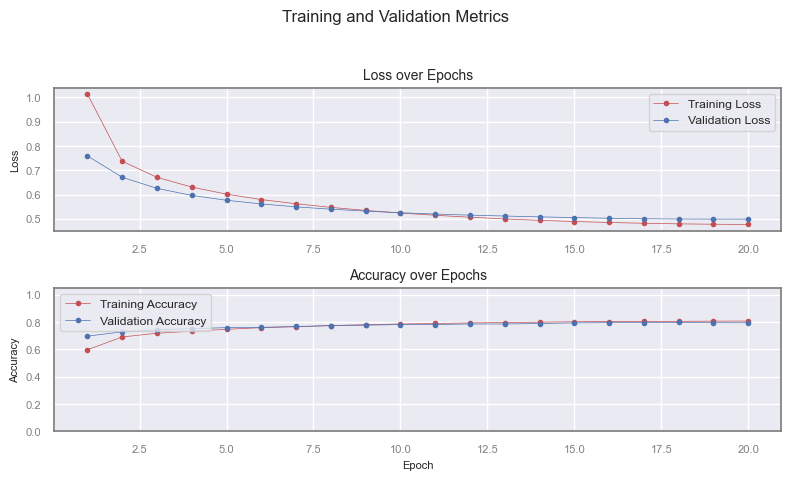

Final Training Loss:     0.4770
Final Training Accuracy: 0.8071
Final Validation Accuracy: 0.7946

--- Training w/ Cosine Decay (Initial Learning Rate = 0.0005) ---


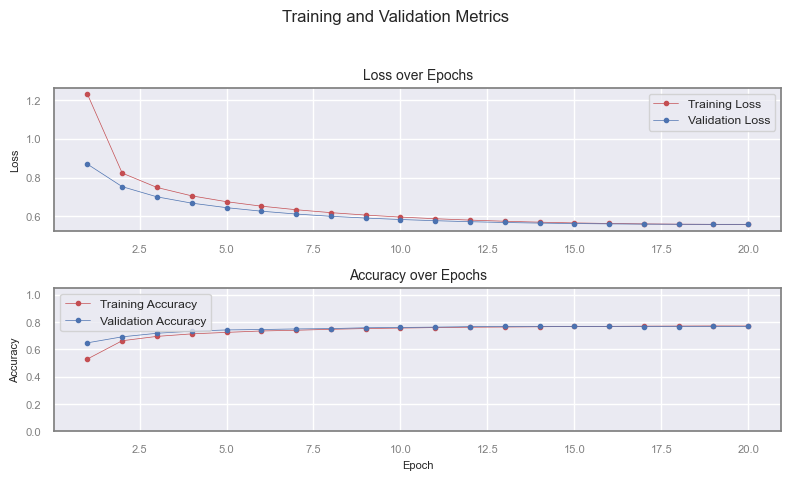

Final Training Loss:     0.5585
Final Training Accuracy: 0.7708
Final Validation Accuracy: 0.7678

--- Training w/ Cosine Decay (Initial Learning Rate = 0.0001) ---


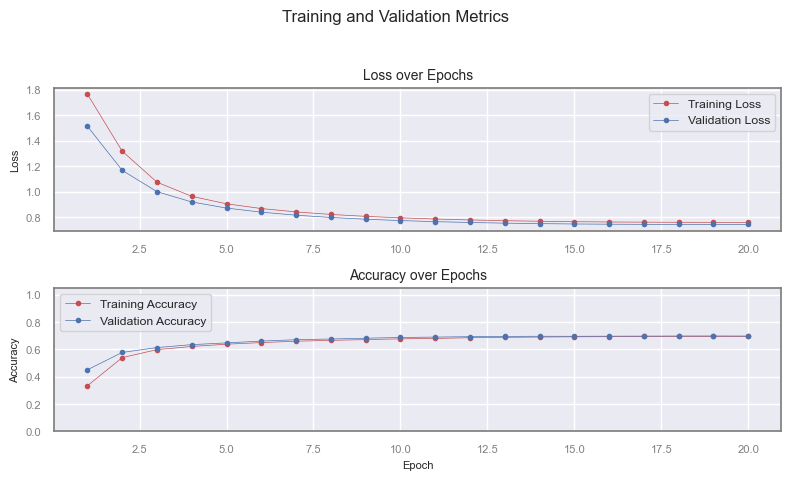

Final Training Loss:     0.7607
Final Training Accuracy: 0.6947
Final Validation Accuracy: 0.6973

Best Initial LR for Cosine Decay: 0.01
Final Training Accuracy: 0.8803
Final Validation Accuracy: 0.8352


,Initial Learning Rate,Training Accuracy,Validation Accuracy
0,0.0100,0.880322,0.835153
1,0.0050,0.880192,0.842174
2,0.0010,0.807125,0.794592
3,0.0005,0.770786,0.767811
4,0.0001,0.694728,0.697348


In [380]:
# Your code here

initial_learning_rates = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
batch_size      = 32
num_epochs      = 20
results_cosine_decay = {}

# number of steps (batches) per epoch
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))

# Total number of training steps (needed for per-step schedulers like CosineDecay)
total_steps = num_epochs * steps_per_epoch


for initial_lr in initial_learning_rates:
    print(f"\n--- Training w/ Cosine Decay (Initial Learning Rate = {initial_lr}) ---")

    # Define the learning rate scheduler
    lr_schedule = CosineDecay(
        initial_learning_rate = initial_lr,
        decay_steps           = total_steps,
        alpha                 = 0.0  # Final learning rate as a fraction of initial_lr
    )
    
    # Create  model again to reset weights for each experiment
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])
    
    # Compile using  scheduler for  learning rate
    model.compile(
        optimizer     = Adam(learning_rate = lr_schedule),
        loss          = "sparse_categorical_crossentropy",
        metrics       = ['accuracy']
    )
    
    # Train 
    history = model.fit(
        X_train_scaled, y_train,
        epochs          = num_epochs,
        batch_size      = batch_size,
        validation_data = (X_test_scaled, y_test),
        verbose         = 0
    )
    
    plot_history(history)
    
    # final training accuracy
    final_training_accuracy             = history.history['accuracy'][-1]
    final_validation_accuracy           = history.history['val_accuracy'][-1]
    # results_cosine_decay[initial_lr]    = final_training_accuracy
    
    
    results_cosine_decay[initial_lr]    = (final_training_accuracy, final_validation_accuracy)

# initial learning rate with best accuracy
best_initial_lr         = max(results_cosine_decay, key = lambda x: results_cosine_decay[x][0])
best_training_accuracy_cosine    = results_cosine_decay[best_initial_lr][0]
best_validation_accuracy_cosine  = results_cosine_decay[best_initial_lr][1]

print(f"\nBest Initial LR for Cosine Decay: {best_initial_lr}\nFinal Training Accuracy: {best_training_accuracy_cosine:.4f}\nFinal Validation Accuracy: {best_validation_accuracy_cosine:.4f}")
results_df_cosine = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in results_cosine_decay.items()],
    columns=['Initial Learning Rate', 'Training Accuracy', 'Validation Accuracy']
)
results_df_cosine

In [392]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = best_initial_lr            # Replace 0.0 with your answer

In [393]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [383]:
# Set a4b to the best accuracy found

a4b = best_training_accuracy_cosine            # Replace 0.0 with your answer

In [394]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8803


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the **test set**
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

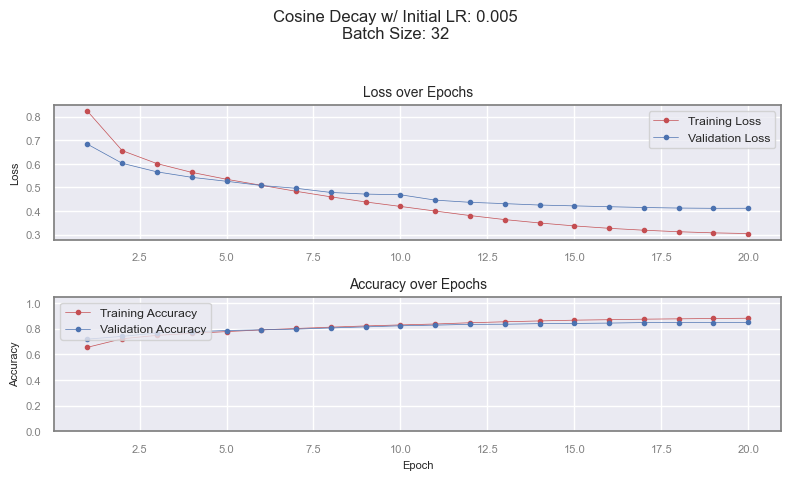

Final Training Loss:     0.3048
Final Training Accuracy: 0.8813
Final Validation Accuracy: 0.8484

Final Test Loss:     0.4120
Final Test Accuracy: 0.8484


,Initial Learning Rate,Batch Size,Training Accuracy,Validation Accuracy,Test Loss,Test Accuracy
0,0.005,32,0.881298,0.848414,0.411986,0.848414


In [397]:
# Your code here -- add as many cells as you need

# Best hyperparameters from previous experiments
best_initial_lr = .005
best_batch_size = 32
num_epochs      = 20

#  total number of training steps for  scheduler
steps_per_epoch = int(np.ceil(len(X_train_scaled) / best_batch_size))
total_steps     = num_epochs * steps_per_epoch

#  learning rate scheduler
lr_schedule = CosineDecay(
    initial_learning_rate = best_initial_lr,
    decay_steps = total_steps,
    alpha = 0.0
)

# final model
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer   = Adam(learning_rate = lr_schedule),
    loss        = "sparse_categorical_crossentropy",
    metrics     = ['accuracy']
)

# Train with best hyperparameters
history = model.fit(
    X_train_scaled, y_train,
    epochs          = num_epochs,
    batch_size      = best_batch_size,

    validation_data = (X_test_scaled, y_test),
    verbose         = 0
)

plot_history(history, title=f"Cosine Decay w/ Initial LR: {best_initial_lr}\nBatch Size: {best_batch_size}")

best_training_accuracy_p5 = history.history['accuracy'][-1]
best_validation_accuracy_p5 = history.history['val_accuracy'][-1]

# Evaluate on  test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)


print(f'\nFinal Test Loss:     {test_loss:.4f}')
print(f'Final Test Accuracy: {test_accuracy:.4f}')

results_df_p5 = pd.DataFrame({
    'Initial Learning Rate': [best_initial_lr],
    'Batch Size': [best_batch_size],
    'Training Accuracy': [best_training_accuracy_p5],
    'Validation Accuracy': [best_validation_accuracy_p5],
    'Test Loss': [test_loss],
    'Test Accuracy': [test_accuracy]
})
results_df_p5

In [398]:
# history.history

In [399]:
# Set a5a to the best training accuracy found by your best model

a5a = best_training_accuracy_p5            # Replace 0.0 with your answer

In [400]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8813


In [401]:
# Set a5b to the test accuracy found by your best model

a5b = test_accuracy            # Replace 0.0 with your answer

In [402]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8484


## Reflection Questions (ungraded)


1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

<font color='plum'>

   a.) Training Time would &uarr; b/c there's more data to process; specifically, epoch would take longer to complete because the model has to perform more forward and backward passes to compute the gradients and update the weights for the larger dataset.

   b.) Best Batch Size would likely &uarr; b/c a larger batch size provides a more stable, accurate estimate of the true gradient -->  faster and more stable convergence.

   c.) Best learning rate would  &darr;. As batch size increases, each gradient update becomes more stable and more accurately reflects the overall data distribution. Consequently, we can often use a lower learning rate to make more precise and controlled updates. Additionally, with a larger dataset, each epoch is longer and provides more opportunities for the model to learn. A smaller learning rate can help prevent the model from overshooting the optimal solution and lead to better fine-tuning.


2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

   <font color = 'plum'> There are trade-offs. 

   Smaller batch sizes -->  better generalization because they introduce more **noise** into the gradient descent process.

   * **Noise in the Gradient:** Each update to the model's weights is based on a small, noisy estimate of the true gradient. This noise helps the optimization process avoid getting stuck in a sharp, non-generalizable minimum. Instead, it pushes the model toward a flatter, more generalizable minimum in the loss landscape. 
   * **Regularization:** The stochastic nature of small batches acts as a form of implicit **regularization**, similar to a form of noise injection. It prevents the model from relying too heavily on the specific patterns of a single large batch, forcing it to learn more robust features that apply to the entire dataset.


  Larger batch sizes require compensating for the loss of gradient noise. Two approaches:

1.  **&darr; Learning Rate** when using a large batch size. Since each gradient update is a more stable estimate of the true gradient, each smaller step is still in the right direction. A high learning rate with a large batch can cause the model to overshoot the minimum.


2.  **Add Explicit Regularization** techniques to the model to prevent overfitting such as:

   - **Weight Decay (L2 Regularization)** which adds a penalty to the loss function based on the magnitude of the model's weights, encouraging the model to use smaller, more stable weights.
   - **Dropout,** which randomly sets a fraction of the neuron outputs to zero during training, which then prevents neurons from co-adapting and forces the model to learn more robust features.


3. **More epochs, same Learning Rate.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 
<font color='plum'>


**Training loss** would likely **decrease**, and **training accuracy** would likely **increase** .

* With more epochs, the model has more opportunities to see the entire training dataset and adjust its weights. This allows it to continue learning the patterns in the data, which leads to a better fit. As the model fits the training data more closely, its training loss will go down and its training accuracy will go up.


Test accuracy would likely **increase initially**, then **plateau or decrease** over time.

* Initially, the model would continue to learn generalizable features, so its performance on the test set would improve, and the test accuracy would increase.

* However, after a certain point, the model may start to **overfit** to the training data (learning the noise or specific nuances of the training set rather than underlying, generalizable patterns.) Performance on unseen test data will start to decline, even though training accuracy continues to rise.


4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

   <font color='plum'>

   Not exactly.  When we compared the models trained with a fixed number of epochs (20), the ones with a **higher learning rate** generally achieved better results. For example, in Problem 3, the learning rate of `0.001` yielded the best validation accuracy. The lower learning rates resulted in worse performance after the same number of epochs, suggesting that they were not able to converge as effectively within the given training time.

   A very low learning rate can cause the model to move too slowly through the loss landscape, and it may not have enough epochs to find a good minimum. Conversely, a learning rate that is too high might cause the model to overshoot the minimum. The goal of hyperparameter tuning is to find the **optimal balance** that allows the model to learn effectively and converge to the best possible solution within the given constraints.

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


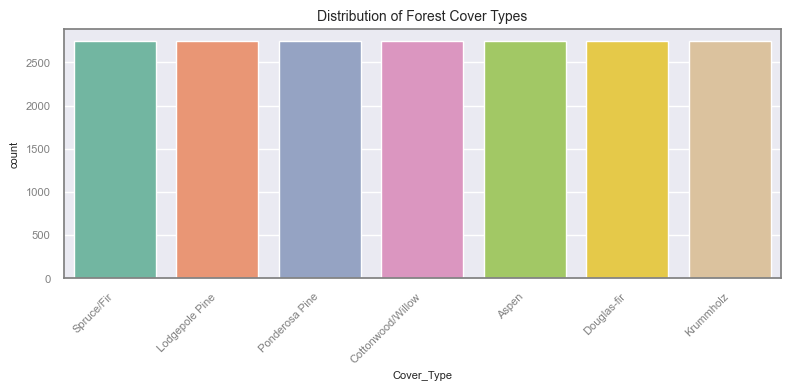

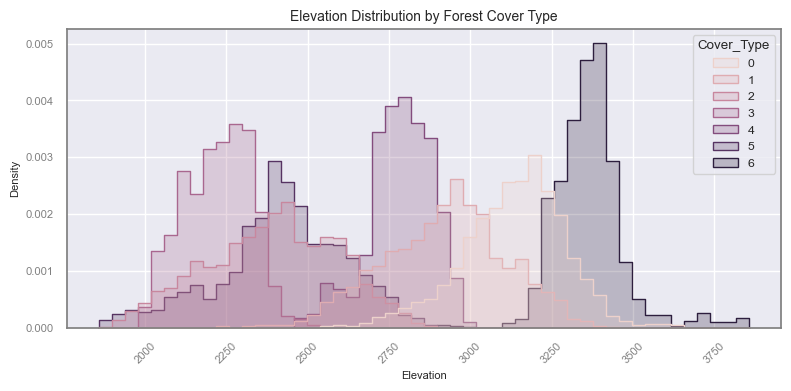

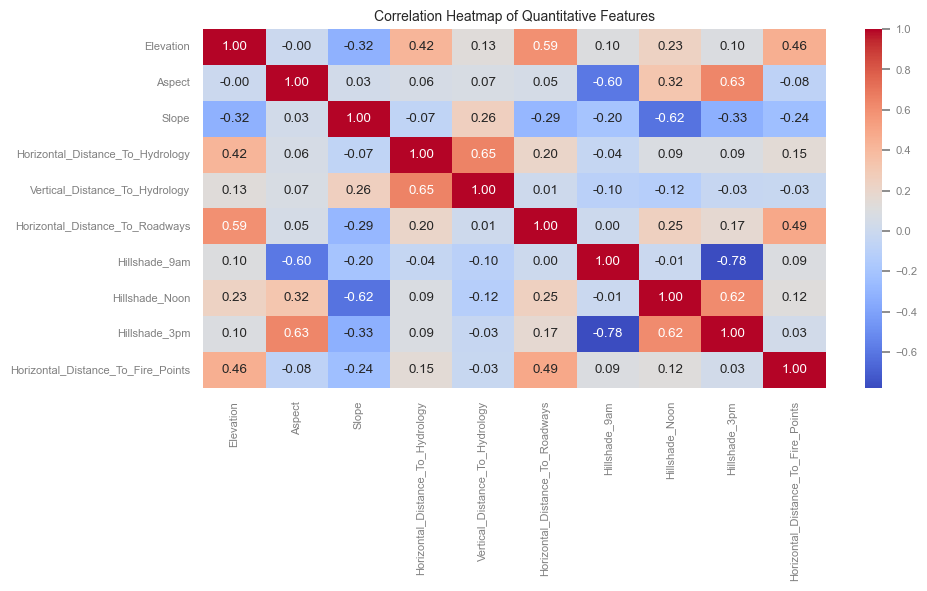

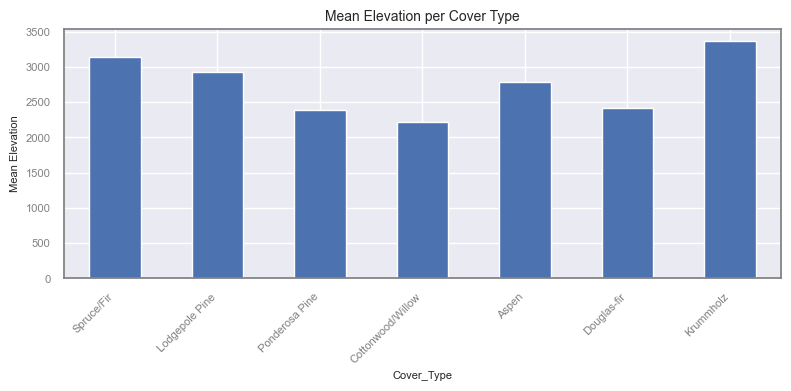

In [391]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.tight_layout()
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.tight_layout()
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,6))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.tight_layout()
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.tight_layout()
plt.show()


## For reference

### <font color='plum'> Batch Size
 **batch size** is a hyperparameter in a neural network that defines the number of training examples processed together in a single iteration before the model's weights are updated.

Instead of updating the model after every single training example (which is slow and unstable) or after the entire dataset (which is memory-intensive and can get stuck in poor solutions), neural networks are typically trained using a method called **mini-batch gradient descent**. The batch size is the size of these "mini-batches."

### How Batch Size Works

During training, the neural network performs two main steps for each batch:

1.  **Forward Pass**: The batch of training examples is fed into the network, and a prediction is made for each one.
2.  **Backward Pass**: The difference between the predictions and the actual values (the "error") is calculated. The network then uses this error to compute the gradient, which tells it how to adjust its internal weights to reduce the error. 

This process is repeated for each batch until the entire dataset has been processed. One complete pass through the entire dataset is called an **EPOCH**.


### The Trade-offs of Batch Size

The choice of batch size is a critical trade-off that affects the training process in several ways:

* **Computational Efficiency**: Larger batch sizes make better use of the parallel processing capabilities of modern hardware like GPUs, leading to faster training times per epoch. However, they require more memory.
* **Training Stability**: Larger batches --> more accurate estimate of the overall gradient --> smoother, more stable weight updates --> faster convergence.
* **Generalization**: Smaller batch sizes introduce more "noise" or randomness into the gradient estimates. This noise can actually be beneficial, as it helps the model avoid getting stuck in a local minimum and can lead to a better, more generalized solution on unseen data. Conversely, very large batch sizes can sometimes lead to models that don't generalize as well.
* **Memory Constraints**: The main practical limitation for batch size is <u>the amount of memory on your GPU or other hardware.</u> If the batch size is too large, the training process will fail with an out-of-memory error.

Common batch sizes are typically powers of two, such as 32, 64, 128, or 256, because they align well with computer memory architecture. Choosing the right batch size often involves experimentation to find a balance that provides good performance, fast training, and effective generalization for your specific problem.